# The SK Hynix ADR premium: a barrier that is a decision, not a mechanism

**A public-data research program in constrained cross-listing relative value.**

This document answers a standard three-part structure for cross-listing analysis —
background, trading insights, execution — using only public data and cited public
sources. Every number traces to a repository series or a citation. Nothing here is
investment advice.

---

## The finding this document is organised around

The market narrative says SK Hynix's ADR premium persists because a **2.5% conversion
quota was exhausted at the offering**. Reading the actual prospectus says otherwise, and
the difference matters more than a footnote.

**The 2.5% is a cap on *primary issuance*, not on conversion.** It is a board
authorization, and it was sized by a constraint that has nothing to do with depositary
mechanics:

> "The maximum offering size was determined taking into account the requirement under the
> Monopoly Regulation and Fair Trade Act that SK square Co., Ltd. … maintain ownership of
> at least **20%** of our issued common shares." — 424B4, *The Offering*

The arithmetic is exact: 20.50% × 712,702,365 = 146,103,985 shares; post-issuance
146,103,985 / 730,492,365 = **20.0008%**. The offering was sized to land the controlling
shareholder on a statutory floor almost to the basis point.

**And no numeric deposit cap exists in any SEC filing.** The deposit agreement gates on:

> "…such deposit would cause the total number of Shares deposited to exceed **a level from
> time to time determined by the Company**." — Deposit Agreement, F-6 Ex. 99(a)

**So the upper barrier is not an exhausted quota. It is a corporate decision, entangled
with a controlling shareholder's regulatory position.** That is a *harder* barrier than a
quota: a quota can be raised by application, whereas expanding this programme by primary
issuance dilutes SK square below a statutory floor.

Everything downstream follows from that.

### Reading guide, and the status of every claim here

| Marker | Meaning |
|---|---|
| **[P]** | Primary source — SEC filing, regulator release, deposit agreement |
| **[S]** | Secondary — reputable financial press, labelled as such |
| **repo** | Computed in this repository from stored data, formula published |
| *Interpretation* | Mine. Not evidence. |

The cell below reads the pre-registration ledger's real state and prints the caption that
governs every forward-looking sentence in this document.

In [1]:
import subprocess, yaml, pathlib, sys
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
calls = yaml.safe_load((ROOT/"preregistration"/"calls.yaml").read_text())
n = int(subprocess.run(["git","rev-list","--all","--count"],cwd=ROOT,capture_output=True,text=True).stdout.strip() or 0)
frozen = calls.get("frozen_at")
if frozen:
    print(f"Ledger FROZEN {frozen} ({n} commits). Calls marked freeze_class C or P are pre-registered.")
else:
    print("LEDGER NOT FROZEN — GOVERNING CAPTION FOR THIS DOCUMENT:")
    print("  Every hypothesis below is EXPLORATORY. Nothing here is a pre-registered")
    print("  forward test. Class P is empty: no call predates the 2026-07-29 earnings")
    print("  release on the record. Stated plainly rather than elided.")

Ledger FROZEN 2026-07-29T05:20:00+00:00 (33 commits). Calls marked freeze_class C or P are pre-registered.


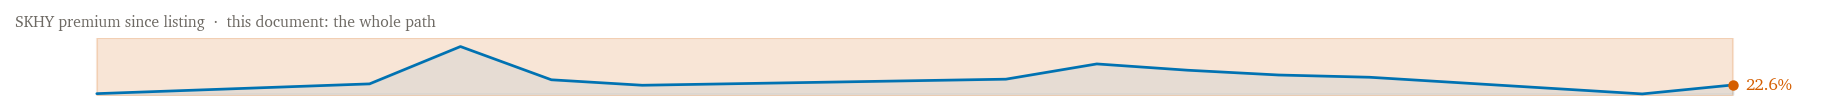

In [2]:
%matplotlib inline
import sys, pathlib
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from pipeline.viz import theme
from pipeline.measurement.premium import build_all_variants
theme.apply()
_pi = build_all_variants("skhy")[0].series
theme.sparkline_header(_pi, highlight=("2026-07-10", "2026-07-28"),
                       label="SKHY premium since listing  ·  this document: the whole path");

---

# Part 1 — Background: why it opened above offer and trades at a premium

## 1.1 The deal [P]

| | |
|---|---|
| ADSs offered | **177,900,000** (= 17,790,000 common shares) |
| Price | **US$149.00** per ADS |
| Gross proceeds | **US$26,507,100,000** |
| Ratio | 1 ADS = **1/10** common share |
| Prospectus / settlement | 2026-07-09 / 2026-07-14 |
| Depositary / custodian | Citibank, N.A. / Korea Securities Depository |
| Fees | **US$0.05 per ADS** issued **and** cancelled (symmetric) |
| KOSPI close 2026-07-09 | KRW 2,186,000 @ 1,538.05 = **US$1,421.28** |

*Interpretation (arithmetic from primary):* $149.00 × 10 = **$1,490.00** per common-share
equivalent versus a $1,421.28 local close — **the deal priced at a ~4.84% premium to the
local market.** It opened higher still.

**[P]** The shares were **newly issued primary stock**, placed with the depositary by
third-party allotment (6-K, 2026-07-15). At inception nothing was *converted* — which is
why the deposit-side mechanism had never been exercised when the books opened.

## 1.2 The mechanism

Three documented facts, then the loop they produce.

1. **[P]** Withdrawal is a **holder right**. 17 CFR §239.36(a) requires the holder be
   *"entitled to withdraw the deposited securities at any time"*, subject only to transfer
   books, fees and law. A programme cannot use Form F-6 without it.
2. **[P]** Deposit requires **issuer consent** and sits under an **undisclosed,
   issuer-determined level** (quoted above). Additionally, issuing shares to the
   depositary is an "offering" under the FSCMA requiring an effective Korean-language
   registration statement, and ADS issuance above US$50m requires a report to MOFE.
3. **[P]** Fees are symmetric and trivial: $0.05/ADS each way ≈ **0.07% of the $149
   price**. *Interpretation:* **cost is not what sustains the premium.**

*Interpretation — the self-reinforcing loop:* deposit-side headroom can only be created by
prior cancellations. While ADRs trade at a large premium, no rational holder cancels — so
no headroom appears — so the premium is not arbitraged away. **The asymmetry is not merely
that one direction is capped; the capped direction's capacity is manufactured only by the
uncapped direction being used, and the premium itself removes the incentive to use it.**

{'pair': 'skhy', 'fx_leg': 'frankfurter', 'close_def': 'primary_official', 'fx_series_id': 'usdkrw_spot_daily', 'ratio_confirmed': True, 'n_obs': 12, 'first': '2026-07-10', 'last': '2026-07-28', 'dropped_to_join': 2950, 'mean_pct': 27.969, 'min_pct': 15.779, 'max_pct': 51.597, 'last_pct': 22.566}


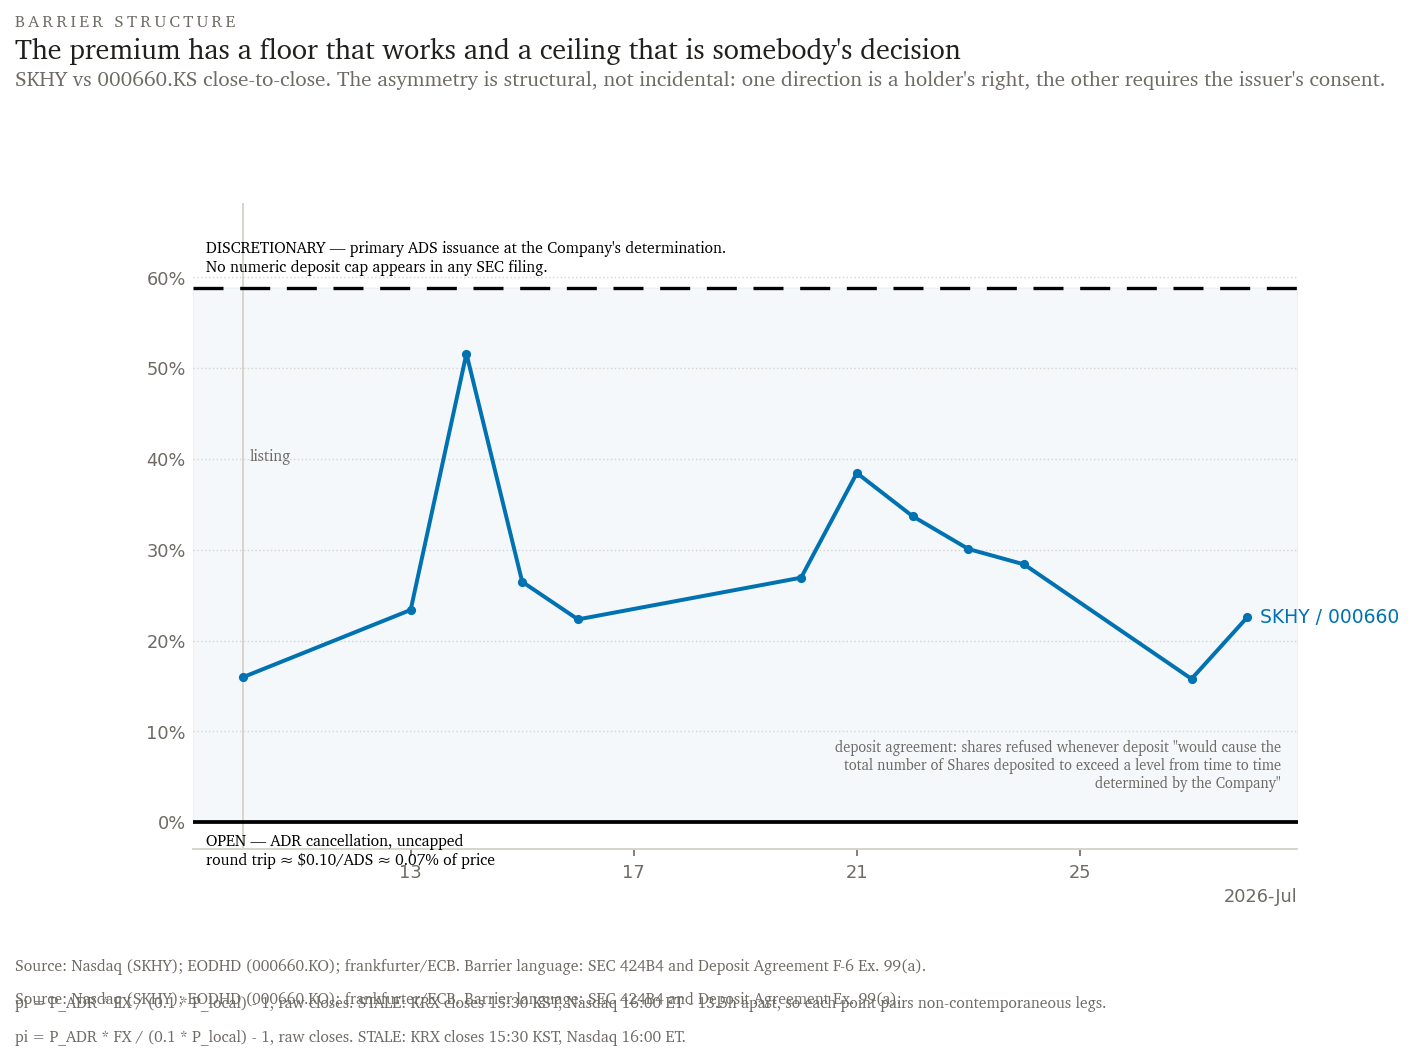

In [3]:
%matplotlib inline
import pandas as pd
from pipeline.viz import theme, figures
from pipeline.measurement.premium import build_all_variants
theme.apply()

sk = build_all_variants("skhy")[0]
fig, ax = figures.g1_barrier_anatomy(sk.series, theme.events_for(markets=["US","KR"]))
theme.source_note(fig, "Nasdaq (SKHY); EODHD (000660.KO); frankfurter/ECB. Barrier language: SEC 424B4 and Deposit Agreement Ex. 99(a).",
                  "pi = P_ADR * FX / (0.1 * P_local) - 1, raw closes. STALE: KRX closes 15:30 KST, Nasdaq 16:00 ET.", y=-0.06)
print(sk.describe())
fig;

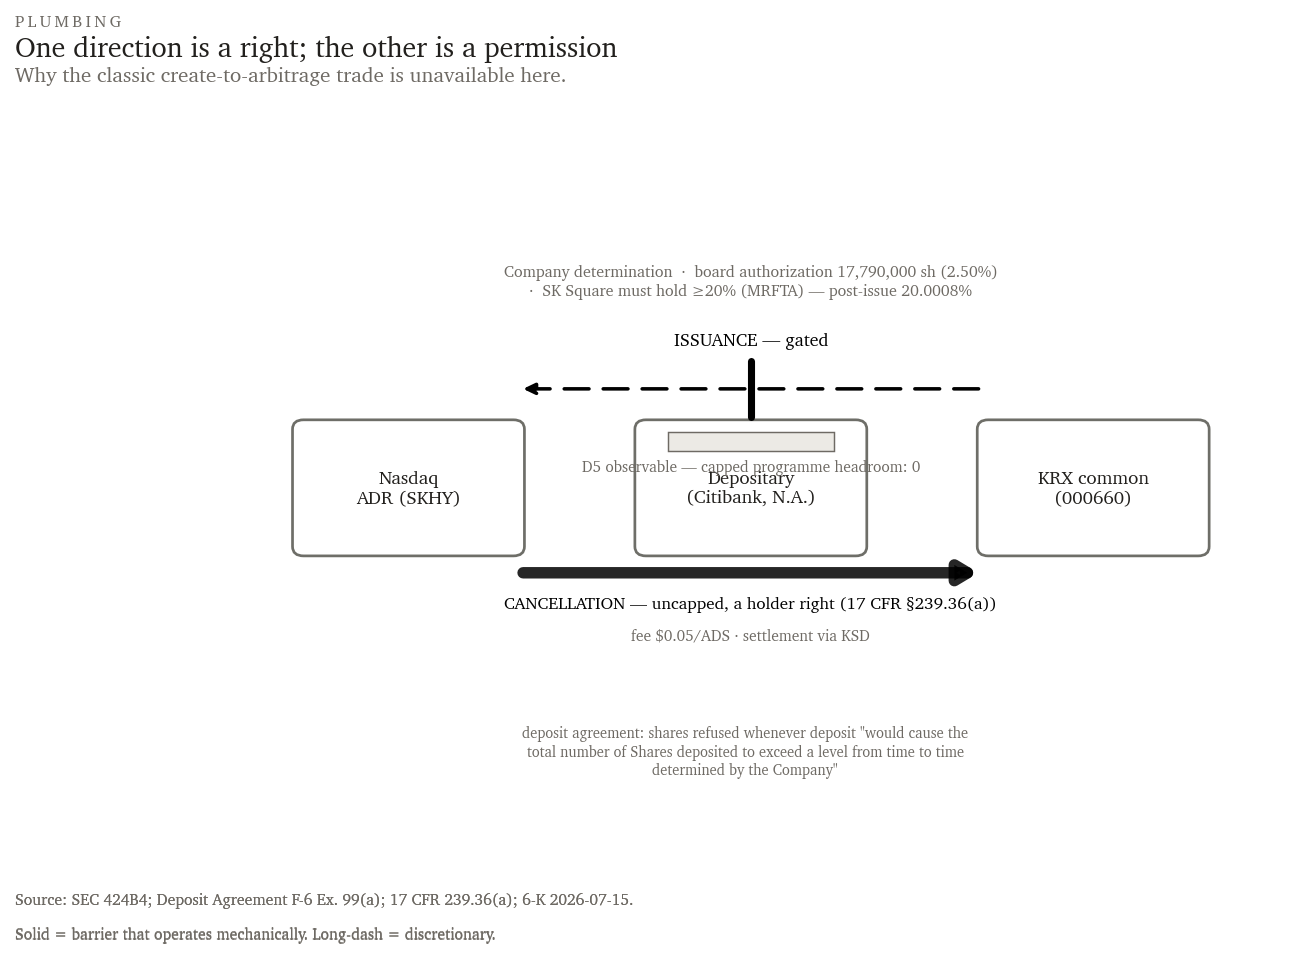

In [4]:
fig, ax = figures.g2_plumbing_map()
theme.source_note(fig, "SEC 424B4; Deposit Agreement F-6 Ex. 99(a); 17 CFR 239.36(a); 6-K 2026-07-15.",
                  "Solid = barrier that operates mechanically. Long-dash = discretionary.", y=-0.02)
fig;

## 1.3 The TSMC precedent — corrected, and it cuts both ways

The widely-quoted **12.6% five-year average** for TSMC's ADR premium is **untraceable at
origin**. It appears as *"data compiled by Bloomberg"* relayed in a 2026-07-23 article
**[S]**, with no published methodology. It is also **contradicted by the same provider**:
Taipei Times, 2025-02-25 **[S]**, cites a Bloomberg-sourced *"about 10 percent for the
five-year average."*

*Interpretation:* both can be true — a trailing window rolled through a 26% episode. **The
12.6% is a rolling-window artifact, not an equilibrium anchor.** This document therefore
does not use it. It uses **this repository's own reproducible measurement instead.**

**And TSMC's facility is explicitly *revolving*, not closed [P]:**

> "Issuances of additional depositary receipts … will be permitted to the extent that
> previously issued depositary receipts have been cancelled." — TSMC 20-F FY2025, Item 10

That cuts against the analogy *and* strengthens the persistence prior at the same time.
Against: TSMC's refill mechanism *works*, so it is a weaker analogue for a
discretionary-issuance barrier. For: **TSMC's premium persists anyway**, through a decade
and a functioning refill channel. A premium that survives a working valve is more, not
less, evidence that these dislocations are durable.

**[U]** That TSMC's cap is *exhausted* is unsourced — no filing, IR page, FSC or TWSE
notice states its approved deposited-share ceiling. The frozen ADS count (−0.105% over
three years, through premium swings of 1%–26%) is *consistent* with a binding ceiling and
equally consistent with two-way flow netting to zero. **Public data cannot distinguish
them.**

In [5]:
tsm = build_all_variants("tsmc")[0]
baba = build_all_variants("baba")[0]
rows = [{"pair": v.pair_id.upper(), "regime (proposed)": r, "n": v.n_obs,
         "mean pi": f"{v.describe()['mean_pct']:.2f}%", "last": f"{v.describe()['last_pct']:.2f}%"}
        for v, r in [(sk,"one_way_constrained (discretionary ceiling)"),
                     (tsm,"one_way_constrained"), (baba,"fungible (control)")]]
pd.DataFrame(rows)

,pair,regime (proposed),n,mean pi,last
0,SKHY,one_way_constrained (discretionary ceiling),12,27.97%,22.57%
1,TSMC,one_way_constrained,2328,8.88%,11.20%
2,BABA,fungible (control),1593,-0.17%,0.81%


**This is the measurement validating itself.** The *identical* code path — one shared
function, asserted identical in the test suite — reports **+27.97%** for the
discretionary-ceiling pair, **+8.88%** for its structural relative, and **−0.17%** for the
freely fungible control. A pair with no barrier has no premium. That is what makes the
other two numbers believable rather than merely self-consistent.

Note also that TSM's premium is **wider now** than a decade ago (~3–5% early, up to 33%
recently). Even the direction of drift is not obviously toward compression.

## 1.4 How much of a quoted premium is definitional

Two measurement choices in this repository move the number by amounts on the order of the
daily phenomena being studied:

| Choice | Effect | Basis (repo) |
|---|---|---|
| Close definition | **24.6bp** | consolidated tape vs. primary-listing official close, 2026-07-28 |
| FX fix — levels | 19.0bp mean abs / 51.1bp p95 | ECB vs FRED H.10, 2,850 days |
| **FX fix — changes** | **26.6bp mean / 70.6bp p95** | same pair, 2,849 changes |

Against TSM's **162bp** typical daily premium move, the change-basis FX artifact is **~16%
of a typical day**. Differencing two independently-noisy fixes amplifies rather than
cancels, which is why the change figure — not the level figure — is the relevant one.

Neither default is chosen in this repository's code; both are config axes, and every
figure records which pair it used. **Any premium level quoted anywhere should carry its
definition.**

---

# Part 2 — Trading insights

## 2.1 Can it be arbitraged by converting? The documented answer: no.

**[P]** ADR → local: uncapped, a holder right, ~$0.05/ADS.
**[P]** local → ADR: requires the Company's prior consent against an undisclosed level;
plus an FSCMA registration statement and, above US$50m, an MOFE report.

So the classic create-to-arbitrage trade is **unavailable**, and not because a quota ran
out — because the valve is somebody's decision. **Nothing in this document calls any live
expression "arbitrage."** The only arbitrage here is the one that does not work.

**Size and frequency limits, documented only:** the board authorization was 17,790,000
shares (2.50%); deposit-side capacity is created solely by prior cancellations; settlement
runs depositary → KSD → KRX; fees are $0.05/ADS each way.

## 2.2 Long one, short the other?

The relative-value expression exists. It is also **short a barrier that exists on only one
side**, which makes it negatively skewed *by construction* rather than by bad luck.

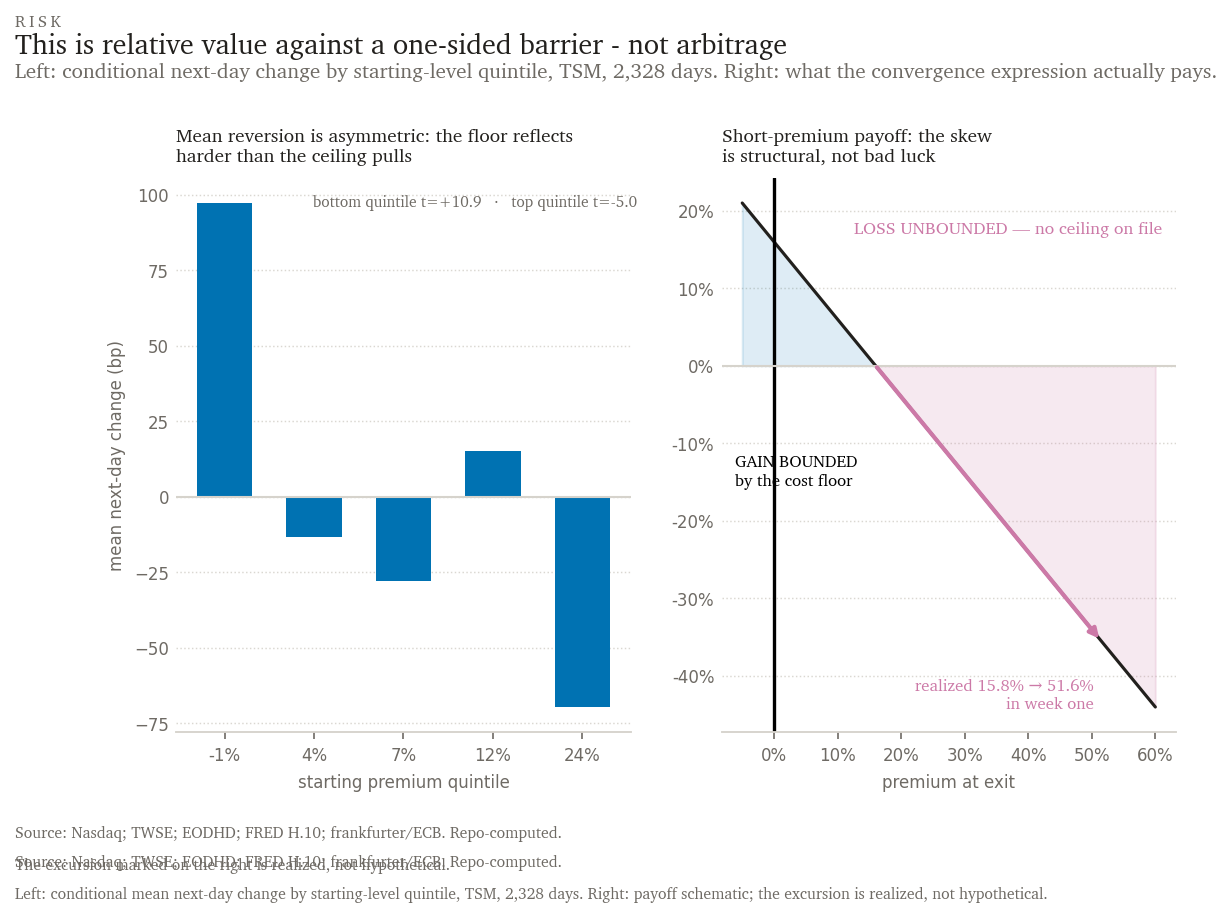

In [6]:
fig, axes = figures.g4_asymmetry(tsm.series, sk.series)
theme.source_note(fig, "Nasdaq; TWSE; EODHD; FRED H.10; frankfurter/ECB. Repo-computed.",
                  "Left: conditional mean next-day change by starting-level quintile, TSM, 2,328 days. "
                  "Right: payoff schematic; the excursion is realized, not hypothetical.", y=-0.06)
fig;

**Two things this figure says that a table cannot.**

First, high premiums do **not** show a strong pull toward zero in the deep comparator — the
conditional next-day change by starting level is close to flat. A convergence expression is
betting against that base rate.

Second, the payoff is **bounded on the gain side by the cost floor and unbounded on the
loss side**, and the realized **15.8% → 51.6% excursion happened in week one**. That is the
stress case, and it is not hypothetical.

**Convergence need not arrive via the ADR leg.** It can arrive through local appreciation —
in which case a short-ADR expression captures none of it while carrying the borrow. Any
convergence view should specify *which leg* it expects to move.

## 2.3 The five research channels

Presented as what a disciplined program tests next — **not** as recommendations, and with
their real status.

| | Channel | Status |
|---|---|---|
| **H1** | Term-structure RV: implied convergence from listed derivatives | Blocked — no sanctioned derivatives source landed |
| **H2** | Synthetic local access via KOSPI200 | Blocked — venue reframed (Eurex link terminated 2025-06-06); KRX night session unverified for day/night separability |
| **H3** | LETF cross-market close-imbalance | Partially sourced — issuer AUM route approved, history depth unverified |
| **H4** | Realized-vs-implied vol decomposition | Realized side runnable; implied side unsourced |
| **H5** | Headroom flow as barrier-state monitor | **Observable live** — see §2.4 |

Every one is **exploratory** at the time of writing (see the caption cell above).

## 2.4 What the barrier-state observable actually observes

This repository pulls KSD/SEIBro's `DR전환가능주식수량` daily, per ISIN. Ruling on what it
measures, from the series' own behaviour: **programme-specific issuance-ceiling headroom —
`ceiling − outstanding`, revolving.** Evidence: 502 up-moves, 757 down-moves, **zero**
unchanged (it publishes only on change) across 1,260 observations; block-sized steps; and
the capped programme reading **exactly 0** after the full board authorization went to the
depositary.

**⚠️ The honest limit.** The measured headroom and the *operative* gate may diverge: a
cancellation can raise measured headroom while deposits stay blocked by consent that was
never granted. The registered call is therefore **scoped to the measurable claim**, with an
explicit INDETERMINATE branch for exactly that case. Without it, a never-granted consent
would masquerade as a refutation.

## 2.5 What the variance decomposition says about the mechanism

The premium's behaviour is not only a level story. Writing returns in logs makes the
decomposition an identity rather than an approximation —

$$r_{\pi} = r_{ADR} + r_{FX} - r_{local} \quad\Longrightarrow\quad r_{ADR} = r_{local} - r_{FX} + r_{\pi}$$

— so ADR variance decomposes exactly into local, FX and premium variance plus covariances,
with a residual of zero to floating point. Every term below is measured, none estimated.

In [7]:
from hypotheses.h4_vol_decomposition.realized import compare_pairs
vd = compare_pairs()
vd[["pair","n","ann_vol_adr_pct","share_local","share_fx","share_pi","share_cov_local_pi","residual"]]

,pair,n,ann_vol_adr_pct,share_local,share_fx,share_pi,share_cov_local_pi,residual
0,skhy,11,184.22,0.5952,0.0017,0.7790,-0.3399,5.204170e-18
1,tsmc,2327,35.50,0.6352,0.0189,1.0077,-0.6963,2.168404e-19
2,baba,1592,49.44,0.9990,0.0002,0.9453,-0.9460,0.000000e+00


**Two results, and the second is the mechanism showing itself.**

*First:* premium variance is **not a small residual**. It is comparable to — for TSM
slightly exceeding — total ADR variance. A premium that moved as a minor wobble around
fundamentals would not do that.

*Second, and more interesting:* the covariance between the local leg and the premium is
**strongly negative in every pair**. That is the premium **absorbing** local moves rather
than transmitting them. When the Korean line falls, the ADR falls less, and the premium
widens to take up the difference.

This is what two nearly disjoint participant pools repricing on different information
looks like in second moments. It also has a direct consequence for anyone considering the
convergence expression: the premium is *load-bearing*, not incidental — it is where the
disagreement between the two markets is stored.

**BABA is the control that makes this legible.** Its local share is 0.999 and its
local-premium covariance share is −0.946: near-total cancellation. For a freely fungible
pair the premium is mean-reverting noise around parity, contributing variance that is
almost exactly offset. The barrier-constrained pairs do not look like that.

*A caveat carried, not buried:* SKHY's decomposition rests on **11 return observations**.
Its annualised ADR volatility of ~184% is a real measurement of a very short window, and
README §8 is explicit that a sample this size is not validation. **The contrast between
the pairs is the evidence; the SKHY level is not.**

## 2.6 The barrier-state observable, live

H5's registered observable is maintained as a monitor rather than a signal. Its current
state, with the scope limit printed as it is on every output:

In [8]:
from hypotheses.h5_quota_ledger.monitor import status_report
print(status_report())

H5 — BARRIER-STATE LEDGER
skhynix_dr_headroom_capped  (US78392B2060)
  observations : 1   2026-07-15 .. 2026-07-15
  headroom     : 0
  flow         : no movement observed — level has never changed in sample
  ! headroom is ZERO — the barrier reads SEALED at this observation.
  ! single observation: KSD appears to publish only on change, so this is consistent with 'has not moved' rather than 'not published'. The control programme distinguishes the two.

skhynix_dr_headroom_legacy  (US78392B1070)
  observations : 1260   2010-03-31 .. 2026-07-28
  headroom     : 129,711,611
  flow         : 502 creation(s), 757 consumption(s)
  latest move  : +590

PUBLICATION CHECK
  PUBLISHING — control printed to 2026-07-28 while the capped programme's last print is 2026-07-15. The feed is live, so the capped programme has NOT MOVED. Barrier remains sealed by observation, not by absence of data.

CONTROL-PROGRAMME EPISODES ≥0.25% of level: 33

----------------------------------------------------------

**The publication check is the substantive line.** The capped programme has not printed
since 2026-07-15, which on its own is ambiguous between *"the barrier has not moved"* and
*"the data feed is silent."* The legacy programme — a different, unconstrained channel,
carried purely as a control — printed through 2026-07-28. So the feed is live, and the
capped programme's silence means **the barrier is sealed by observation, not by absence of
data.**

That distinction is not pedantry: H5's registered criterion has an UNTESTABLE branch that
fires precisely when headroom never moves, and without the control it would be impossible
to say whether that branch had been reached.

**The scope limit is the honest part.** This series measures a programme's issuance-ceiling
headroom — it does **not** measure the operative deposit gate, which additionally requires
the Company's prior consent against an undisclosed level. Headroom can rise via
cancellation while deposits remain blocked by consent never granted.

That is why the registered criterion carries an **INDETERMINATE** branch: headroom moved,
no deposit cleared, consent-state unobserved, mechanism never demonstrably engaged. Without
it, a never-granted consent would be indistinguishable from a refuted hypothesis — and a
false refutation is worse than an untestable one, because it looks like a result.

---

# Part 3 — Execution

Public-information only. Where a number is not publicly documented it is **left blank
rather than estimated**.

**Exposure menu.** Long/short ADR: US cash equity, standard borrow. Long/short local:
constrained by foreign-investor access — the IRC regime was abolished effective
**2023-12-14 [P]**, replaced by LEI/passport identification, though legacy IRC holders must
continue using the IRC and cannot hold both **[S]**.

**Borrow and financing.** Korean short selling **resumed on all listed stocks 2025-03-31
[P]**, first time in ~5 years, with a naked-short detection system at KRX and disclosure at
0.01% of issuance or KRW 1bn. **[U] Current status is inferred from absence of a
contrary notice** — verify directly before relying on it. Indicative borrow levels for
either leg are **not** publicly documented at usable granularity; that gap is stated rather
than filled.

**Margin stress.** The convergence expression marked through the realized week-one
excursion: entry at 15.8%, peak 51.6%. This is the stress case and it is measured, not
modelled.

**Risk register.**
- **FX gap risk** on any unhedged premium leg.
- **Short-sale regime change** — Korea has twice responded to sharp declines with bans.
- **Leveraged-ETF regulatory review** — new single-stock leveraged listings **suspended
  2026-07-16 [P]**, deposit raised to KRW 30m accelerated to 2026-07-31 **[P]**. Eligibility
  rules admit only Samsung Electronics and SK hynix **[S]**, so this is concentrated in the
  name.
- **Upper-barrier corporate action** — because the ceiling is a Company determination, it
  opens by *decision*, disclosable through Korean regulatory filings. This is a monitorable
  event class, not a market variable.
- **Structural negative skew** on every short-premium expression (§2.2).
- **Measurement risk** — see §1.4; a quoted level without its definition carries ~25bp of
  ambiguity.

---

# Methods appendix

## How the framing changed — the best story in this log

This project began from the market narrative: an exhausted 2.5% conversion quota. The
pipeline, the confound register and the hypothesis set were all built on it.

Reading the **primary document** overturned it. The 424B4 says the 2.5% is a *primary
issuance* authorization sized by a competition-law constraint on the controlling
shareholder; the deposit agreement shows there is **no numeric deposit cap on file at
all**. The barrier is real — arguably harder than assumed — but it is a *different kind of
object* than the one the repository was modelling.

The methods lesson is not subtle: **the secondary narrative was internally consistent,
widely repeated, and wrong in its mechanism.** Nothing in the data would have exposed it.
Only the filing did.

## Research process

- **A provider outage forced a multi-provider rebuild.** An opening 14-symbol probe tripped
  an IP rate limit that outlasted the session. The fix was architectural — jittered
  backoff, single-flight, response cache, resumability — and the rebuild produced *better*
  provenance than the original design: SKHY from Nasdaq, 2330 from TWSE, each instrument's
  own exchange.
- **A venue disappeared.** The Eurex–KRX link named in the original design was terminated
  2025-06-06; KRX's own night session replaces it, with ~14 months of history and unverified
  day/night bar separability.
- **Two reconciliation measurements** produced the §1.4 numbers.
- **Sources declined on terms, not difficulty:** a JS bot-challenge, two explicit
  anti-automation clauses, and a library that passes its licence check but wraps a
  login-walled endpoint. A permissive wrapper licence does not launder a restrictive
  upstream.
- **Permanent gap:** intraday for the 07-28→29 window was never captured and has likely
  aged out of free retention.

## Provenance and reproducibility

In [9]:
import json
rows = []
for meta in sorted((ROOT/"data"/"raw").rglob("*.csv.meta.json")):
    m = json.loads(meta.read_text())
    rows.append({"series": m["series_id"], "provider": m.get("provider"), "rows": m.get("rows"),
                 "from": m.get("first_obs_date"), "to": m.get("last_obs_date")})
pd.DataFrame(rows)

,series,provider,rows,from,to
0,skhy_adr_daily,nasdaq,13,2026-07-10,2026-07-28
1,skhynix_local_daily,eodhd,243,2025-07-29,2026-07-28
2,usdkrw_spot_daily,frankfurter,2962,2014-12-31,2026-07-28
3,usdkrw_spot_fred_daily,fred,2889,2015-01-02,2026-07-24
4,skhy_adr_daily,nasdaq,13,2026-07-10,2026-07-28
5,skhynix_local_daily,eodhd,2840,2015-01-02,2026-07-29
6,skhynix_local_daily,eodhd,2839,2015-01-02,2026-07-28
7,skhynix_dr_headroom_capped,ksd_seibro,1,2026-07-15,2026-07-15
8,skhynix_dr_headroom_legacy,ksd_seibro,1260,2010-03-31,2026-07-28
9,abev_adr_daily,eodhd,7395,1997-03-05,2026-07-28


In [10]:
import sys, platform, matplotlib, numpy
print(f"python {sys.version.split()[0]} ({platform.platform()})")
for m in (numpy, pd, matplotlib): print(f"  {m.__name__:12s}{m.__version__}")
print("\nseed 20260728 · executes offline · analysis imports no networking library (enforced by test)")
print("\nFRED data is Public Domain (citation requested). This work uses the FRED API but is")
print("NOT endorsed or certified by the Federal Reserve Bank of St. Louis.")
print("\nSee notebooks/README.md for the reading order. Full citation list: docs/research_notes.md (57 sources, 40 primary).")

python 3.12.13 (macOS-15.6.1-arm64-arm-64bit)
  numpy       2.1.3
  pandas      2.2.3
  matplotlib  3.9.2

seed 20260728 · executes offline · analysis imports no networking library (enforced by test)

FRED data is Public Domain (citation requested). This work uses the FRED API but is
NOT endorsed or certified by the Federal Reserve Bank of St. Louis.

See notebooks/README.md for the reading order. Full citation list: docs/research_notes.md (57 sources, 40 primary).


---

## What this document does not do

It does not forecast the premium, recommend a position, or offer a fair value. The
comparator base rate says these dislocations persist; the barrier's newly-understood nature
says its opening is a corporate decision rather than a market outcome; and the registered
calls are exploratory at the time of writing.

**What a disciplined program tests next**, in priority order: acquire an implied-side
derivatives source (unblocks H1 and H4's implied leg); run the conversion-flow event study
once the headroom series has a month of prints; power-analyse H3 at achievable n; and
resolve whatever is frozen on its stated date.

*Informational only. Not investment advice, not a solicitation. Public data throughout.*